# Mini-projeto M2 

## Dataset MNIST (Modified National Institute of Standards and Technology)

O **MNIST** é o dataset "Hello World" da visão computacional, ideal para testar métodos de reconhecimento de padrões com um mínimo esforço de pré-processamento.

### Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

* Importar o dataset MNIST via scikit-learn (fetch_openml('mnist_784')) ou via tensorflow.keras.datasets.mnist.


In [2]:
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")


Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


* Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

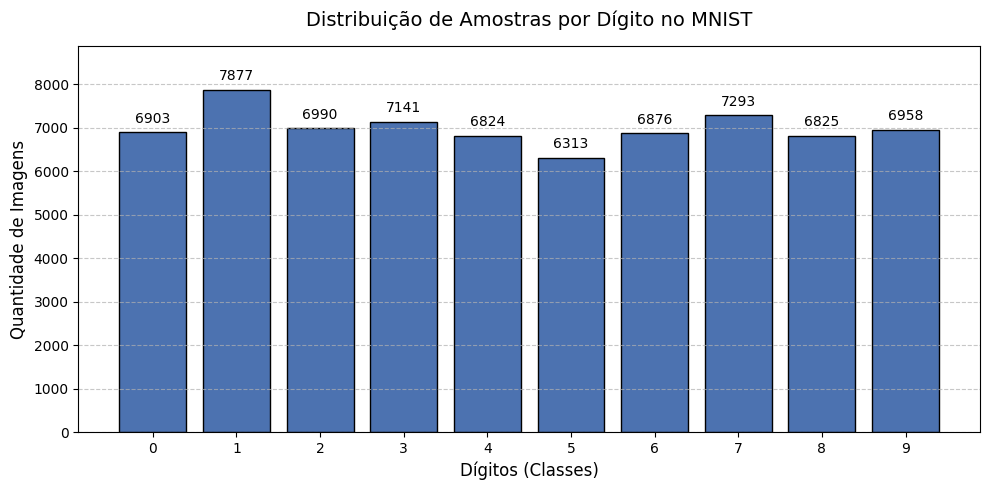

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Descrição completa do dataset
print(mnist.DESCR)
print("Chaves:", mnist.keys())

# Separando as matrizes de features (X) (as imagens) e rótulos/alvo (y) (os rótulos de 0 a 9)
X, y = mnist.data, mnist.target

print("-" * 40)
print("📊 ANÁLISE EXPLORATÓRIA DO MNIST 📊")
print("-" * 40)
print(f"Dimensão de X (Imagens): {X.shape} -> {X.shape[0]} amostras com {X.shape[1]} features cada")
n_pixels = int(np.sqrt(X.shape[1]))
print(f"Formato original de cada feature X: imagem de {n_pixels}x{n_pixels} = {X.shape[1]} pixels")
print(f"Dimensão de y (Rótulos): {y.shape} -> {y.shape[0]} respostas correspondentes")
print(f"Rótulos possíveis: {sorted(set(mnist.target))}")
print("-" * 40)

# -------------------------------------------------------------
# Balanceamento das classes (dígitos de 0 a 9)
classes, contagens = np.unique(y, return_counts=True)
print("\nDistribuição de amostras por dígito:")
for c, count in zip(classes, contagens):
    print(f"Dígito {c}: {count} imagens")

# Vamos fazer um histograma da distribuição
plt.figure(figsize=(10, 5))
barras = plt.bar(classes, contagens, color='#4C72B0', edgecolor='black')

plt.title("Distribuição de Amostras por Dígito no MNIST", fontsize=14, pad=15)
plt.xlabel("Dígitos (Classes)", fontsize=12)
plt.ylabel("Quantidade de Imagens", fontsize=12)
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 150,
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(contagens) + 1000)

plt.tight_layout()
plt.show()


* Gerar uma grade visual  de no mínimo 2 x 5 com matplotlib, exibindo exemplos de imagens de cada dígito junto com seus respectivos rótulos originais.


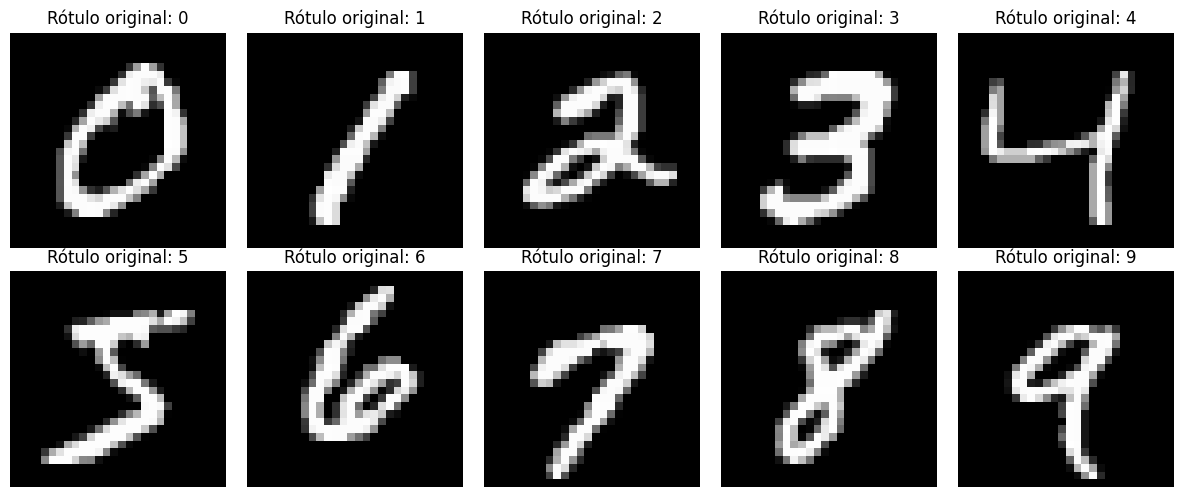

In [ ]:
# Extraindo algumas imagens

# Criamos uma grade 2x5 para exibir um exemplo de cada dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    # Garantimos uma imagem de cada número
    idx = np.where(y == str(i))[0][0]

    imagem_28x28 = X[idx].reshape(28, 28)

    axes[i].imshow(imagem_28x28, cmap='gray')
    axes[i].set_title(f"Rótulo original: {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

* Inserir célula de texto interpretando a estrutura dos dados: explicar o significado da escala de intensidade de pixels (0 a 255) e como imagens bidimensionais (28 x 28) são representadas vetorialmente (784 features).

**Estrutura e Origem**

* **Volume Total:** 70.000 imagens de dígitos manuscritos (0 a 9).

* **Autoria:** Criado a partir de bases do NIST americano, misturando amostras escritas por funcionários do censo (base mais limpa) e estudantes do ensino médio (base mais ruidosa).

**Características Técnicas**

* **Formato Original:** Matrizes de $28 \times 28$ pixels. Os dígitos foram normalizados em tamanho e centralizados calculando o "centro de massa" dos pixels.

* **Vetorização:** Para a maioria dos algoritmos, a matriz bidimensional é "achatada" num vetor $\vec{x}$ de **784 dimensões** (features).

* **Intensidade (Pixels):** Escala de cinza de **0** (fundo) a **255** (traço máximo). Os tons de cinza intermediários são resultado da técnica de *anti-aliasing* usada na redução da imagem original.

Então, temos o seguinte problema: cada imagem $i$ é um vetor $\vec{x}^{(i)} = (x_1^{(i)},..., x_{784}^{(i)})$, em que as componentes $x_{j}^{(i)}$ é um pixel com um valor entre $0$ e $255$. Queremos aprender a classificar esses vetores dentros dos rótulos de $0$ a $9$.

**Balanceamento de Classes**

O dataset apresenta uma distribuição muito equilibrada (sem forte viés para nenhum número específico). As amostras variam de forma suave entre o **dígito 5** (classe minoritária, com 6.313 imagens) e o **dígito 1** (classe majoritária, com 7.877 imagens), com a média girando em torno de 7.000 imagens por número.